# Google Flu Trends: simulating the error mechanism

**This notebook is a SIMULATION of the mechanism, not Google's real data.** The 45 selected queries were never published (Lazer et al., *Science*, 2014, supplement §4). Only the orders of magnitude (50 million candidates, 1,152 training points) come from the papers; every other parameter is a modeling choice.

**Three questions, three experiments**
1. **Selection**: what happens when you pick the best correlations out of a very large number of candidates?
2. **Off-season**: what happens to a model built on "winter detectors" when a non-seasonal epidemic (H1N1-like, 2009) hits?
3. **Drift**: what happens to a frozen model when query volume changes (search interface), and does recalibrating with lagged CDC data help?

**Limits**: this does not prove that this is what happened at Google; it shows that the mechanism produces this kind of error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
plt.rcParams['figure.dpi'] = 110

def season_shape(t, peak=0):
    return np.maximum(0, np.cos(2 * np.pi * (t - peak) / 52)) ** 2

def simulate(seed=0, n_years=12, n_train_years=6, n_noise=10000, n_winter=1000, n_flu=30,
             drift=1.5, outbreak_amp=1.0, noise_winter=0.25, noise_flu=0.25):
    rng = np.random.default_rng(seed)
    T = n_years * 52
    t = np.arange(T); year = t // 52
    train = t < n_train_years * 52; test = ~train
    amp = rng.uniform(0.6, 1.4, size=n_years)
    flu_true = amp[year] * season_shape(t)
    ob_center = (n_train_years + 2) * 52 + 26          # summer epidemic in the test period (H1N1 2009-like)
    flu_true = flu_true + outbreak_amp * np.exp(-0.5 * ((t - ob_center) / 4) ** 2)
    y = flu_true + rng.normal(0, 0.05, T)
    # (A) AR(1) noise, unrelated to flu (vectorised: x[i] = 0.9 x[i-1] + e[i])
    noise = lfilter([1.0], [1.0, -0.9], rng.normal(0, 1, (n_noise, T)), axis=1)
    # (B) "winter" queries: seasonal, unrelated to flu (e.g. high school basketball)
    a = rng.uniform(0.6, 1.4, size=(n_winter, n_years))
    winter = a[:, year] * season_shape(t) + rng.normal(0, noise_winter, (n_winter, T))
    # (C) true flu queries: track flu, including off-season
    flu = flu_true + rng.normal(0, noise_flu, (n_flu, T))
    X = np.vstack([noise, winter, flu])
    kinds = np.array(["noise"] * n_noise + ["winter"] * n_winter + ["flu"] * n_flu)
    # drift: after drift_start, ALL queries are multiplied by `drift`
    # (simple assumption: an interface change inflates search volume)
    drift_start = (n_train_years + 1) * 52
    X_drift = X.copy(); X_drift[:, t >= drift_start] *= drift
    return dict(t=t, y=y, X=X, X_drift=X_drift, kinds=kinds, train=train, test=test,
                flu_true=flu_true, drift_start=drift_start, ob_center=ob_center)

def corr_rows(X, y):
    Xc = X - X.mean(axis=1, keepdims=True); yc = y - y.mean()
    return (Xc @ yc) / (np.linalg.norm(Xc, axis=1) * np.linalg.norm(yc) + 1e-12)

def run(seed=0, k=20, **kw):
    d = simulate(seed=seed, **kw)
    y, X, Xd, kinds, tr, te, t = d["y"], d["X"], d["X_drift"], d["kinds"], d["train"], d["test"], d["t"]
    # FAULTY STEP: pick the k best correlations, computed on the training set only
    r_tr = corr_rows(X[:, tr], y[tr])
    top = np.argsort(-np.abs(r_tr))[:k]
    comp = {kk: int((kinds[top] == kk).sum()) for kk in ["noise", "winter", "flu"]}
    agg = (Xd[top] * np.sign(r_tr[top])[:, None]).mean(axis=0)     # "query fraction"
    A = np.c_[agg[tr], np.ones(tr.sum())]
    coef, *_ = np.linalg.lstsq(A, y[tr], rcond=None)
    pred = coef[0] * agg + coef[1]                                  # static GFT-type model
    lag = np.r_[y[:2], y[:-2]]                                      # baseline: value from 2 weeks ago
    seas = np.r_[y[:52], y[:-52]]
    B = np.c_[agg, lag, seas, np.ones_like(agg)]
    cf, *_ = np.linalg.lstsq(B[tr], y[tr], rcond=None)
    comb = B @ cf
    recal = np.full_like(y, np.nan)                                 # rolling recalibration (104 known weeks, 2-week lag)
    for i in np.where(te)[0]:
        lo, hi = i - 2 - 104, i - 2
        Bw = np.c_[agg[lo:hi], lag[lo:hi], np.ones(hi - lo)]
        cw, *_ = np.linalg.lstsq(Bw, y[lo:hi], rcond=None)
        recal[i] = cw[0] * agg[i] + cw[1] * lag[i] + cw[2]
    mae = lambda p, m: float(np.mean(np.abs(p[m] - y[m])))
    ob = te & (np.abs(t - d["ob_center"]) <= 8)
    post = t >= d["drift_start"]
    peak = post & (y > 0.6)                                         # peak weeks after the drift
    res = dict(
        r_train_top=float(np.mean(np.abs(r_tr[top]))),
        r_test_top=float(np.mean([abs(np.corrcoef(X[i, te], y[te])[0, 1]) for i in top])),
        corr_test_agg=float(np.corrcoef(pred[te], y[te])[0, 1]),
        mae_gft=mae(pred, te), mae_lag=mae(lag, te), mae_comb=mae(comb, te), mae_recal=mae(recal, te),
        mae_gft_ob=mae(pred, ob), mae_lag_ob=mae(lag, ob), mae_recal_ob=mae(recal, ob),
        peak_over=float(np.mean(pred[peak] / y[peak])),             # >1 = overestimate at peaks
        comp=comp, max_noise_r=float(np.max(np.abs(r_tr[kinds == "noise"]))))
    return res, d, pred, lag, recal, top

## 1. The multiple-comparisons problem
Series of **pure noise** (no link with the flu): the more you test, the better the best one correlates with the target by chance alone. Median over 5 draws.

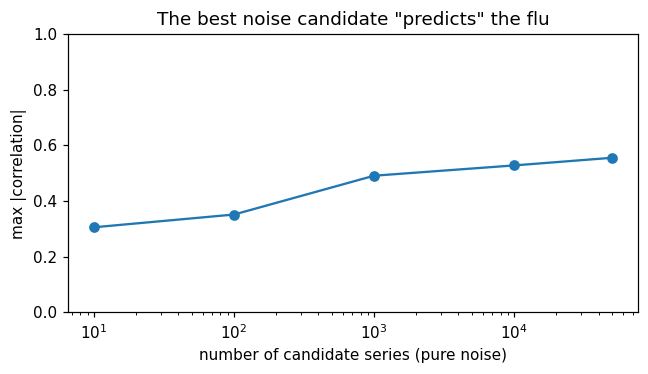

{10: 0.31, 100: 0.35, 1000: 0.49, 10000: 0.53, 50000: 0.56}


In [2]:
rng = np.random.default_rng(1)
T = 312                                    # 6 years of training weeks
y0 = season_shape(np.arange(T)) + rng.normal(0, .05, T)
ns = [10, 100, 1000, 10000, 50000]
best = [np.median([np.abs(corr_rows(lfilter([1], [1, -.9], rng.normal(0, 1, (n, T)), axis=1), y0)).max()
                   for _ in range(5)]) for n in ns]
plt.figure(figsize=(6, 3.5)); plt.semilogx(ns, best, 'o-')
plt.xlabel('number of candidate series (pure noise)'); plt.ylabel('max |correlation|')
plt.title('The best noise candidate "predicts" the flu'); plt.ylim(0, 1); plt.tight_layout(); plt.show()
print(dict(zip(ns, np.round(best, 2))))

## 2. One run (seed 0)
`comp` = composition of the 20 selected queries. `corr_test_agg` is high, yet the error (MAE) is **worse** than simply using the value from 2 weeks ago: **a good correlation is not a good prediction**.

In [3]:
res, d, pred, lag, recal, top = run(seed=0)
for k_, v_ in res.items(): print(f'{k_:14s}', v_ if isinstance(v_, dict) else round(v_, 3))

r_train_top    0.838
r_test_top     0.737
corr_test_agg  0.91
mae_gft        0.131
mae_lag        0.131
mae_comb       0.117
mae_recal      0.108
mae_gft_ob     0.429
mae_lag_ob     0.203
mae_recal_ob   0.291
peak_over      1.03
comp           {'noise': 0, 'winter': 16, 'flu': 4}
max_noise_r    0.549


## 3. The exact step where the error happens: selection by correlation

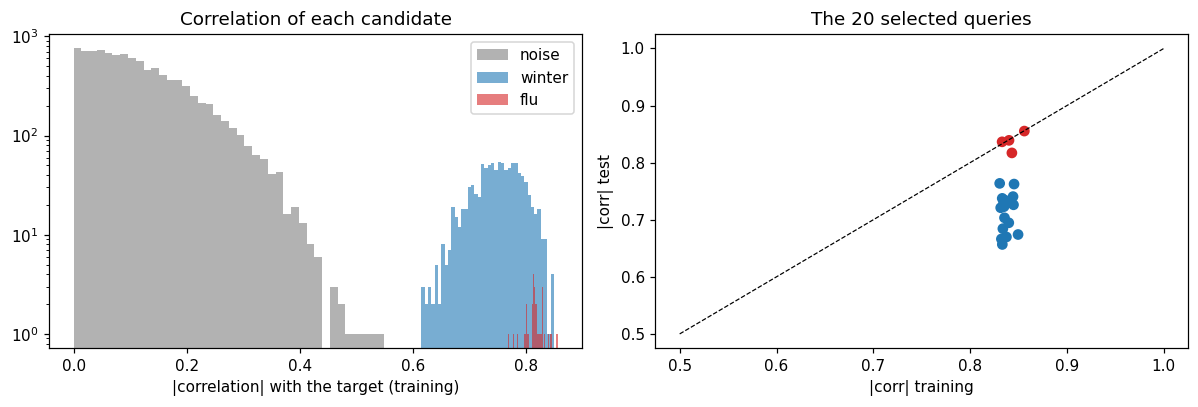

Max correlation among pure-noise series: 0.55
Top-20 composition: {'noise': 0, 'winter': 16, 'flu': 4}


In [4]:
y, X, kinds, tr, te, t = d['y'], d['X'], d['kinds'], d['train'], d['test'], d['t']
r_tr = corr_rows(X[:, tr], y[tr])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for kd, c in [('noise', 'tab:gray'), ('winter', 'tab:blue'), ('flu', 'tab:red')]:
    ax[0].hist(np.abs(r_tr[kinds == kd]), bins=40, alpha=.6, label=kd, color=c)
ax[0].set_yscale('log'); ax[0].set_xlabel('|correlation| with the target (training)'); ax[0].legend()
ax[0].set_title('Correlation of each candidate')
r_te = np.array([np.corrcoef(X[i, te], y[te])[0, 1] for i in top])
col = {'noise': 'tab:gray', 'winter': 'tab:blue', 'flu': 'tab:red'}
ax[1].scatter(np.abs(r_tr[top]), np.abs(r_te), c=[col[k] for k in kinds[top]])
ax[1].plot([0.5, 1], [0.5, 1], 'k--', lw=.8)
ax[1].set_xlabel('|corr| training'); ax[1].set_ylabel('|corr| test'); ax[1].set_title('The 20 selected queries')
plt.tight_layout(); plt.show()
print('Max correlation among pure-noise series:', round(np.abs(r_tr[kinds == 'noise']).max(), 2))
print('Top-20 composition:', res['comp'])

**Reading**: points below the diagonal are queries whose correlation *collapses* out of sample. The "winter" queries (high school basketball) correlate because they share the seasonality, not because they are about flu; this is what Ginsberg et al. themselves observed in their top 100.

## 4. Predictions on seasons never seen

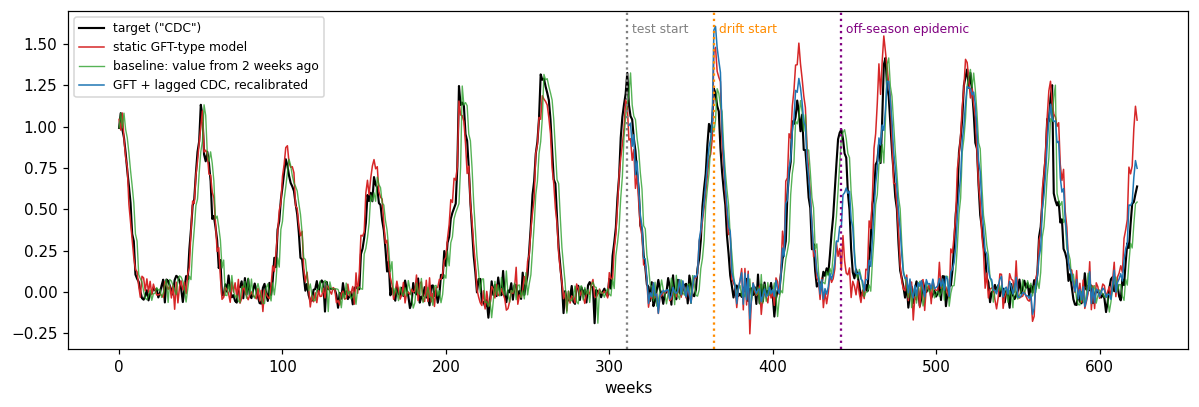

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(t, y, 'k', lw=1.4, label='target ("CDC")')
ax.plot(t, pred, color='tab:red', lw=1, label='static GFT-type model')
ax.plot(t, lag, color='tab:green', lw=.9, alpha=.8, label="baseline: value from 2 weeks ago")
ax.plot(t, recal, color='tab:blue', lw=1, label='GFT + lagged CDC, recalibrated')
top_y = ax.get_ylim()[1]
for x_, lab, c in [(t[tr][-1], 'test start', 'gray'), (d['drift_start'], 'drift start', 'darkorange'),
                   (d['ob_center'], 'off-season epidemic', 'purple')]:
    ax.axvline(x_, color=c, ls=':'); ax.text(x_ + 3, top_y * .92, lab, fontsize=8, color=c)
ax.set_xlabel('weeks'); ax.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

## 5. Robustness: 30 seeds (we don't just show the best one)

In [6]:
rs = [run(s)[0] for s in range(30)]
def m(k_): v = np.array([r[k_] for r in rs]); return v.mean(), v.std()
for k_, lab in [('r_train_top', 'mean corr. (training)'), ('r_test_top', 'mean corr. (test)'),
                ('corr_test_agg', 'aggregated-model corr. (test)'),
                ('mae_gft', 'MAE test: GFT-type model'), ('mae_lag', 'MAE test: value at -2 wks'),
                ('mae_recal', 'MAE test: recalibrated'),
                ('mae_gft_ob', 'MAE epidemic window: GFT-type'), ('mae_lag_ob', 'MAE epidemic window: 2-wk lag')]:
    mu, sd = m(k_); print(f'{lab:38s} {mu:.3f} ± {sd:.3f}')
print()
print('GFT-type worse than 2-wk lag (MAE test):', sum(r['mae_gft'] > r['mae_lag'] for r in rs), '/ 30')
print('Recalibrated better than 2-wk lag:', sum(r['mae_recal'] < r['mae_lag'] for r in rs), '/ 30')
print('True flu queries in the top 20 (avg.):', round(np.mean([r['comp']['flu'] for r in rs]), 1), '/ 20')
print('Noise series in the top 20 (avg.):', round(np.mean([r['comp']['noise'] for r in rs]), 1), '/ 20')

mean corr. (training)                  0.847 ± 0.008
mean corr. (test)                      0.726 ± 0.038
aggregated-model corr. (test)          0.889 ± 0.043
MAE test: GFT-type model               0.140 ± 0.013
MAE test: value at -2 wks              0.126 ± 0.009
MAE test: recalibrated                 0.099 ± 0.013
MAE epidemic window: GFT-type          0.409 ± 0.164
MAE epidemic window: 2-wk lag          0.208 ± 0.009

GFT-type worse than 2-wk lag (MAE test): 25 / 30
Recalibrated better than 2-wk lag: 30 / 30
True flu queries in the top 20 (avg.): 4.4 / 20
Noise series in the top 20 (avg.): 0.0 / 20


## 6. Effect of drift (query volume ×1 / ×1.5 / ×2 after year 7)

In [7]:
for dr in (1.0, 1.5, 2.0):
    rr = [run(s, drift=dr)[0] for s in range(15)]
    print(f"drift x{dr}: GFT-type MAE = {np.mean([r['mae_gft'] for r in rr]):.3f} | recalibrated MAE = {np.mean([r['mae_recal'] for r in rr]):.3f}"
          f" | estimate/actual at peaks = {np.mean([r['peak_over'] for r in rr]):.2f}")

drift x1.0: GFT-type MAE = 0.103 | recalibrated MAE = 0.090 | estimate/actual at peaks = 0.78
drift x1.5: GFT-type MAE = 0.142 | recalibrated MAE = 0.096 | estimate/actual at peaks = 1.17
drift x2.0: GFT-type MAE = 0.234 | recalibrated MAE = 0.101 | estimate/actual at peaks = 1.56


## 7. What this simulation does not prove
- It reproduces neither Google's real data nor its real search terms.
- The GFT-type model is beaten by the simple baseline in the **majority** of seeds, not all of them: the result depends on the parameters.
- Drift is a **modeling assumption** (all queries ×k). Lazer et al. present it as a *probable* explanation, not a proven one.
- The 2009 paper did include an out-of-sample validation (0.97 correlation over 42 weeks). The criticism concerns the selection among a very large number of candidates and the lack of monitoring over time.
- The noise of the "winter" and "flu" queries is deliberately identical (0.25): the setup does not artificially favor the winter detectors.


## Sources
Ginsberg et al., *Nature* 457 (2009) · Lazer, Kennedy, King, Vespignani, *Science* 343 (2014) + supplement · Butler, *Nature* 494 (2013).